<a href="https://colab.research.google.com/github/Khushi27-agg/MachineLearningProjects/blob/main/Titanic_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset (1).csv


In [ ]:
df=pd.read_csv("Titanic-Dataset.csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.shape

(891, 12)

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.describe

<bound method NDFrame.describe of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ...    ...   
886                              Montvila, Rev. Juozas    male  27.0      0   
887                       Graham, Miss. Margaret Edith  female  19.0      0   
888           Johnston, Miss. Catherine Helen "Carrie"  female   NaN      1   
889                              Behr, Mr. Karl Howell    male  26.0      0   
890                                Dooley, Mr. Patrick    male  32.0      0   

     Parch            Ticket     Fare Cabin Embarked  
0        0         A/5 21171   7.2500   NaN        S  
1        0          PC 17599  71.2833   C85        C  
2        0  STON/O2. 3101282   7.9250   NaN        S  
3        0            113803  53.1000  C123        S  
4        0            373450   8.0500   NaN        S  
..     ...               ...      ...   ...      ...  
886      0            211536  13.0000   NaN        S  
887      0            112053  30.0000   B42        S  
888      2        W./C. 6607  23.4500   NaN        S  
889      0            111369  30.0000  C148        C  
890      0            370376   7.7500   NaN        Q  

[891 rows x 12 columns]>

In [ ]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features]
y = df["Survived"]

In [ ]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [ ]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [ ]:
X.isnull().sum()

,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [ ]:
X["Age"] = X["Age"].fillna(X["Age"].median())

/tmp/ipykernel_888/2770350965.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Age"] = X["Age"].fillna(X["Age"].median())


In [ ]:
X['Embarked']=X['Embarked'].fillna(X['Embarked'].mode()[0])

/tmp/ipykernel_888/3863090670.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Embarked']=X['Embarked'].fillna(X['Embarked'].mode()[0])


In [ ]:
X.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
print(X.head())
print(X.dtypes)

   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object


In [ ]:
bool_columns = X.select_dtypes(include="bool").columns

X[bool_columns] = X[bool_columns].astype(int)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 7)
(179, 7)
(712,)
(179,)


In [ ]:
X_train_encoded = pd.get_dummies(X_train, columns=['Sex', 'Embarked'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['Sex', 'Embarked'], drop_first=True)

model = StandardScaler()
X_train_scaled = model.fit_transform(X_train_encoded)
X_test_scaled = model.transform(X_test_encoded)

# **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

In [ ]:
print(type(model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [ ]:
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_LR = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy_LR)
print("Accuracy (%):", accuracy_LR * 100)

Accuracy: 0.8044692737430168
Accuracy (%): 80.44692737430168


In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix_LR = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(confusion_matrix_LR)

Confusion Matrix:
[[98 12]
 [23 46]]


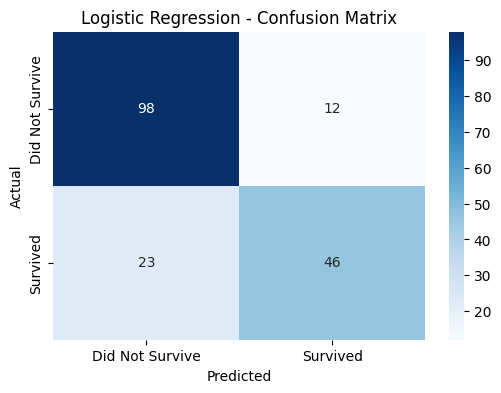

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    confusion_matrix_LR,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_LR = precision_score(y_test, y_pred)
recall_LR = recall_score(y_test, y_pred)
f1_score_LR = f1_score(y_test, y_pred)

print("Precision:", precision_LR)
print("Recall:", recall_LR)
print("F1 Score:", f1_score_LR)

Precision: 0.7931034482758621
Recall: 0.6666666666666666
F1 Score: 0.7244094488188977


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.metrics import roc_auc_score

auc_LR = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc_LR)

ROC-AUC: 0.8433465085638999


# **KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [ ]:
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn = knn.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("Accuracy:", accuracy_knn)
print("Accuracy (%):", accuracy_knn * 100)

Accuracy: 0.8156424581005587
Accuracy (%): 81.56424581005587


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)



In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

print(cm_knn)

[[98 12]
 [21 48]]


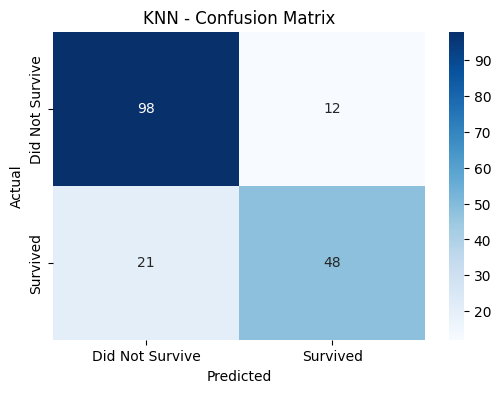

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN - Confusion Matrix")

plt.show()

In [ ]:
print("KNN Accuracy:", accuracy_knn)
print("KNN Precision:", precision_score(y_test, y_pred_knn))
print("KNN Recall:", recall_score(y_test, y_pred_knn))
print("KNN F1 Score:", f1_score(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(cm_knn)

KNN Accuracy: 0.8156424581005587
KNN Precision: 0.8
KNN Recall: 0.6956521739130435
KNN F1 Score: 0.7441860465116279

Confusion Matrix:
[[98 12]
 [21 48]]


In [ ]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



# **Comparison between LR and KNN**

In [ ]:
print("Logistic Regression Accuracy:", accuracy_LR)
print("KNN Accuracy:", accuracy_knn)

print("Logistic Regression F1:", f1_score_LR)
print("KNN F1:", f1_score(y_test, y_pred_knn))

Logistic Regression Accuracy: 0.8044692737430168
KNN Accuracy: 0.8156424581005587
Logistic Regression F1: 0.7244094488188977
KNN F1: 0.7441860465116279


# **Best value of K**

In [ ]:
k_values = range(1, 21)

accuracies = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train)

    predictions = knn_model.predict(X_test_scaled)

    acc = accuracy_score(y_test, predictions)
    accuracies.append(acc)

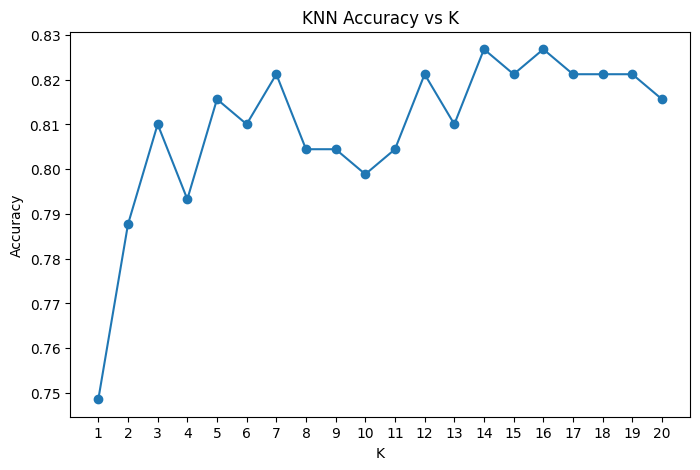

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, accuracies, marker="o")

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.xticks(k_values)

plt.show()

In [ ]:
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 14
Best Accuracy: 0.8268156424581006


In [ ]:
from sklearn.model_selection import cross_val_score

k_values = range(1, 21)

cv_scores = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn_model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_scores.append(scores.mean())

In [ ]:
best_k_cv = k_values[np.argmax(cv_scores)]
best_cv_score = max(cv_scores)

print("Best K:", best_k_cv)
print("Best CV Accuracy:", best_cv_score)

Best K: 8
Best CV Accuracy: 0.8202600216684723


In [ ]:
best_knn = KNeighborsClassifier(n_neighbors=best_k_cv)

best_knn.fit(X_train_scaled, y_train)

final_pred = best_knn.predict(X_test_scaled)

In [ ]:
print("Final Accuracy:", accuracy_score(y_test, final_pred))

print("\nClassification Report:")
print(classification_report(y_test, final_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))

Final Accuracy: 0.8044692737430168

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.85       110
           1       0.83      0.62      0.71        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179


Confusion Matrix:
[[101   9]
 [ 26  43]]


# **SVM**

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model = SVC(kernel="linear")

In [ ]:
svm_model.fit(X_train_scaled, y_train)

SVC(kernel='linear')

In [ ]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)
print("SVM Accuracy (%):", svm_accuracy * 100)

SVM Accuracy: 0.776536312849162
SVM Accuracy (%): 77.6536312849162


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy : 0.776536312849162
Precision: 0.7377049180327869
Recall   : 0.6521739130434783
F1 Score : 0.6923076923076923

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       110
           1       0.74      0.65      0.69        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179


Confusion Matrix:
[[94 16]
 [24 45]]


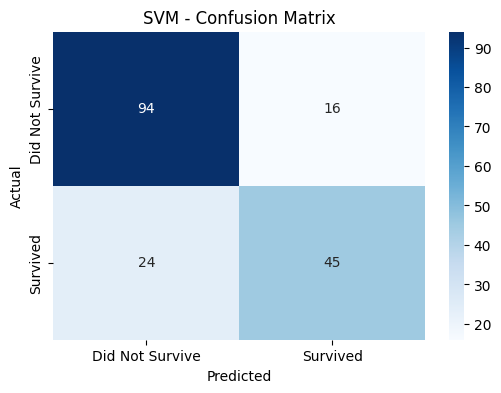

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM - Confusion Matrix")

plt.show()

# RBF **KERNEL**

In [ ]:
svm_rbf = SVC(kernel="rbf")
#C = 1.0 default value
#gamma = "scale"  default value

In [ ]:
svm_rbf.fit(X_train_scaled, y_train)

SVC()

In [ ]:
y_pred_rbf = svm_rbf.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

rbf_accuracy = accuracy_score(y_test, y_pred_rbf)
rbf_precision = precision_score(y_test, y_pred_rbf)
rbf_recall = recall_score(y_test, y_pred_rbf)
rbf_f1 = f1_score(y_test, y_pred_rbf)

print("RBF SVM Accuracy :", rbf_accuracy)
print("RBF SVM Precision:", rbf_precision)
print("RBF SVM Recall   :", rbf_recall)
print("RBF SVM F1 Score :", rbf_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbf))

RBF SVM Accuracy : 0.8100558659217877
RBF SVM Precision: 0.8431372549019608
RBF SVM Recall   : 0.6231884057971014
RBF SVM F1 Score : 0.7166666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       110
           1       0.84      0.62      0.72        69

    accuracy                           0.81       179
   macro avg       0.82      0.78      0.79       179
weighted avg       0.81      0.81      0.80       179



In [ ]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
print(cm_rbf)

[[102   8]
 [ 26  43]]


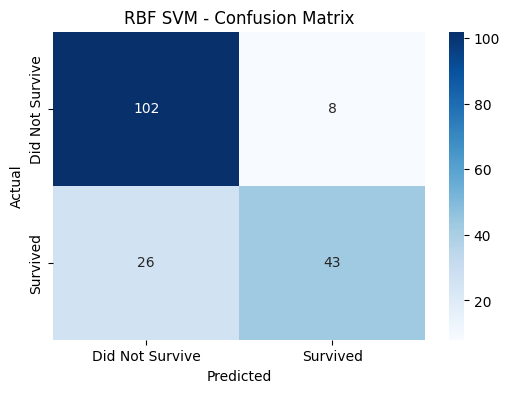

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rbf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RBF SVM - Confusion Matrix")

plt.show()

# **Comparison b/w Linear and RBF Kernel**

In [ ]:
print("              Accuracy    Precision    Recall    F1")
print("Linear SVM:   ", svm_accuracy, svm_precision, svm_recall, svm_f1)
print("RBF SVM:      ", rbf_accuracy, rbf_precision, rbf_recall, rbf_f1)

              Accuracy    Precision    Recall    F1
Linear SVM:    0.776536312849162 0.7377049180327869 0.6521739130434783 0.6923076923076923
RBF SVM:       0.8100558659217877 0.8431372549019608 0.6231884057971014 0.7166666666666667


# **Understand C**

Small C
   ↓
"I can tolerate some mistakes."
   ↓
Smoother / simpler boundary
   ↓
Less risk of overfitting


Large C
   ↓
"Training mistakes are NOT acceptable."
   ↓
More complex boundary
   ↓
Higher risk of overfitting

In [ ]:
C_values = [0.01, 0.1, 1, 10, 100]

c_accuracies = []

for c in C_values:
    svm_model_c = SVC(
        kernel="rbf",
        C=c
    )

    svm_model_c.fit(X_train_scaled, y_train)

    predictions = svm_model_c.predict(X_test_scaled)

    acc = accuracy_score(y_test, predictions)

    c_accuracies.append(acc)

    print("C =", c, "Accuracy =", acc)

C = 0.01 Accuracy = 0.6145251396648045
C = 0.1 Accuracy = 0.7932960893854749
C = 1 Accuracy = 0.8100558659217877
C = 10 Accuracy = 0.8044692737430168
C = 100 Accuracy = 0.7653631284916201


# **Test Gamma**

In [ ]:
gamma_values = [0.001, 0.01, 0.1, 1, 10]

gamma_accuracies = []

for gamma in gamma_values:
    svm_model_gamma = SVC(
        kernel="rbf",
        C=1,
        gamma=gamma
    )

    svm_model_gamma.fit(X_train_scaled, y_train)

    predictions = svm_model_gamma.predict(X_test_scaled)

    acc = accuracy_score(y_test, predictions)

    gamma_accuracies.append(acc)

    print("Gamma =", gamma, "Accuracy =", acc)

Gamma = 0.001 Accuracy = 0.776536312849162
Gamma = 0.01 Accuracy = 0.7877094972067039
Gamma = 0.1 Accuracy = 0.8156424581005587
Gamma = 1 Accuracy = 0.7877094972067039
Gamma = 10 Accuracy = 0.7541899441340782


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(
    SVC(kernel="rbf"),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'gamma': [0.001, 0.01, 0.1, 1, 10]},
             scoring='accuracy')

In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'C': 10, 'gamma': 0.1}
Best CV Score: 0.8258938244853737


In [ ]:
best_svm = grid_search.best_estimator_
y_pred_best_svm = best_svm.predict(X_test_scaled)

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_best_svm))

print("Precision:",
      precision_score(y_test, y_pred_best_svm))

print("Recall:",
      recall_score(y_test, y_pred_best_svm))

print("F1:",
      f1_score(y_test, y_pred_best_svm))

Accuracy: 0.8044692737430168
Precision: 0.8148148148148148
Recall: 0.6376811594202898
F1: 0.7154471544715447


In [ ]:
print(classification_report(y_test, y_pred_best_svm))

#Confusion matrix:

cm_best_svm = confusion_matrix(y_test, y_pred_best_svm)

print(cm_best_svm)

              precision    recall  f1-score   support

           0       0.80      0.91      0.85       110
           1       0.81      0.64      0.72        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179

[[100  10]
 [ 25  44]]


# **Naive Bayes**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled,y_train)

GaussianNB()

In [ ]:
y_train_nb = nb_model.predict(X_train_scaled)
y_test_nb = nb_model.predict(X_test_scaled)

In [ ]:
#Evaluation
nb_accuracy = accuracy_score(y_test, y_test_nb)
nb_precision = precision_score(y_test,y_test_nb),
nb_recall=recall_score(y_test,y_test_nb)
nb_f1=f1_score(y_test,y_test_nb)

print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Accuracy : 0.7821229050279329
Precision: (0.7272727272727273,)
Recall   : 0.6956521739130435
F1 Score : 0.7111111111111111


In [ ]:
print(classification_report(y_test, y_test_nb))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83       110
           1       0.73      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [ ]:
cm_nb=confusion_matrix(y_test,y_test_nb)
print(cm_nb)

[[92 18]
 [21 48]]


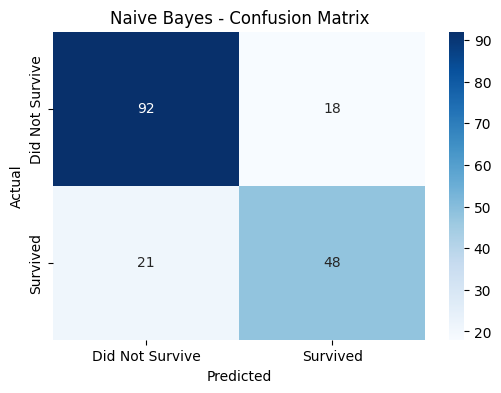

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes - Confusion Matrix")

plt.show()

In [ ]:
probabilities = nb_model.predict_proba(X_test_scaled)

print("Probabilities:")
print(probabilities)

Probabilities:
[[9.92934818e-01 7.06518220e-03]
 [9.64733417e-01 3.52665833e-02]
 [8.93066810e-01 1.06933190e-01]
 [9.94076652e-01 5.92334849e-03]
 [6.02969349e-02 9.39703065e-01]
 [4.82553400e-01 5.17446600e-01]
 [2.73840079e-01 7.26159921e-01]
 [7.70200793e-01 2.29799207e-01]
 [1.85863335e-02 9.81413667e-01]
 [9.37891792e-01 6.21082080e-02]
 [6.93537339e-01 3.06462661e-01]
 [9.91950826e-01 8.04917352e-03]
 [4.38119143e-01 5.61880857e-01]
 [7.54310543e-01 2.45689457e-01]
 [1.88334087e-09 9.99999998e-01]
 [6.84401727e-01 3.15598273e-01]
 [9.82973809e-01 1.70261913e-02]
 [9.68770588e-01 3.12294119e-02]
 [9.61784518e-01 3.82154822e-02]
 [2.71938481e-01 7.28061519e-01]
 [9.68770588e-01 3.12294119e-02]
 [2.15261164e-01 7.84738836e-01]
 [9.69454970e-01 3.05450304e-02]
 [4.30650100e-01 5.69349900e-01]
 [9.69108824e-01 3.08911759e-02]
 [6.68052644e-03 9.93319474e-01]
 [6.93537339e-01 3.06462661e-01]
 [6.76774866e-01 3.23225134e-01]
 [9.03146161e-01 9.68538395e-02]
 [9.03036973e-01 9.69630270e

# **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
tree_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

In [ ]:
tree_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_tree = tree_model.predict(X_test_scaled)

In [ ]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

print("Accuracy :", tree_accuracy)
print("Precision:", tree_precision)
print("Recall   :", tree_recall)
print("F1 Score :", tree_f1)

Accuracy : 0.8212290502793296
Precision: 0.7936507936507936
Recall   : 0.7246376811594203
F1 Score : 0.7575757575757576


In [ ]:
print(classification_report(y_test,y_pred_tree))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



In [ ]:
cm_tree = confusion_matrix(y_test,y_pred_tree)
print("Confusion Matrix:")
print(cm_tree)

Confusion Matrix:
[[97 13]
 [19 50]]


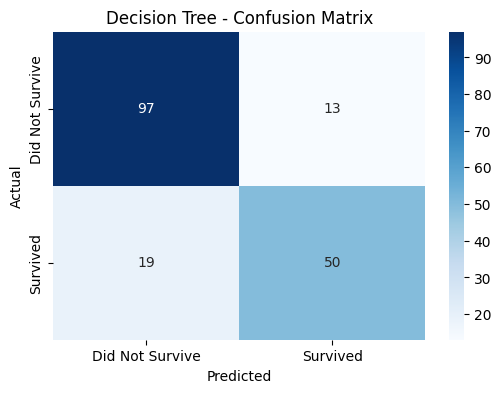

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")

plt.show()

In [ ]:
from sklearn.tree import plot_tree

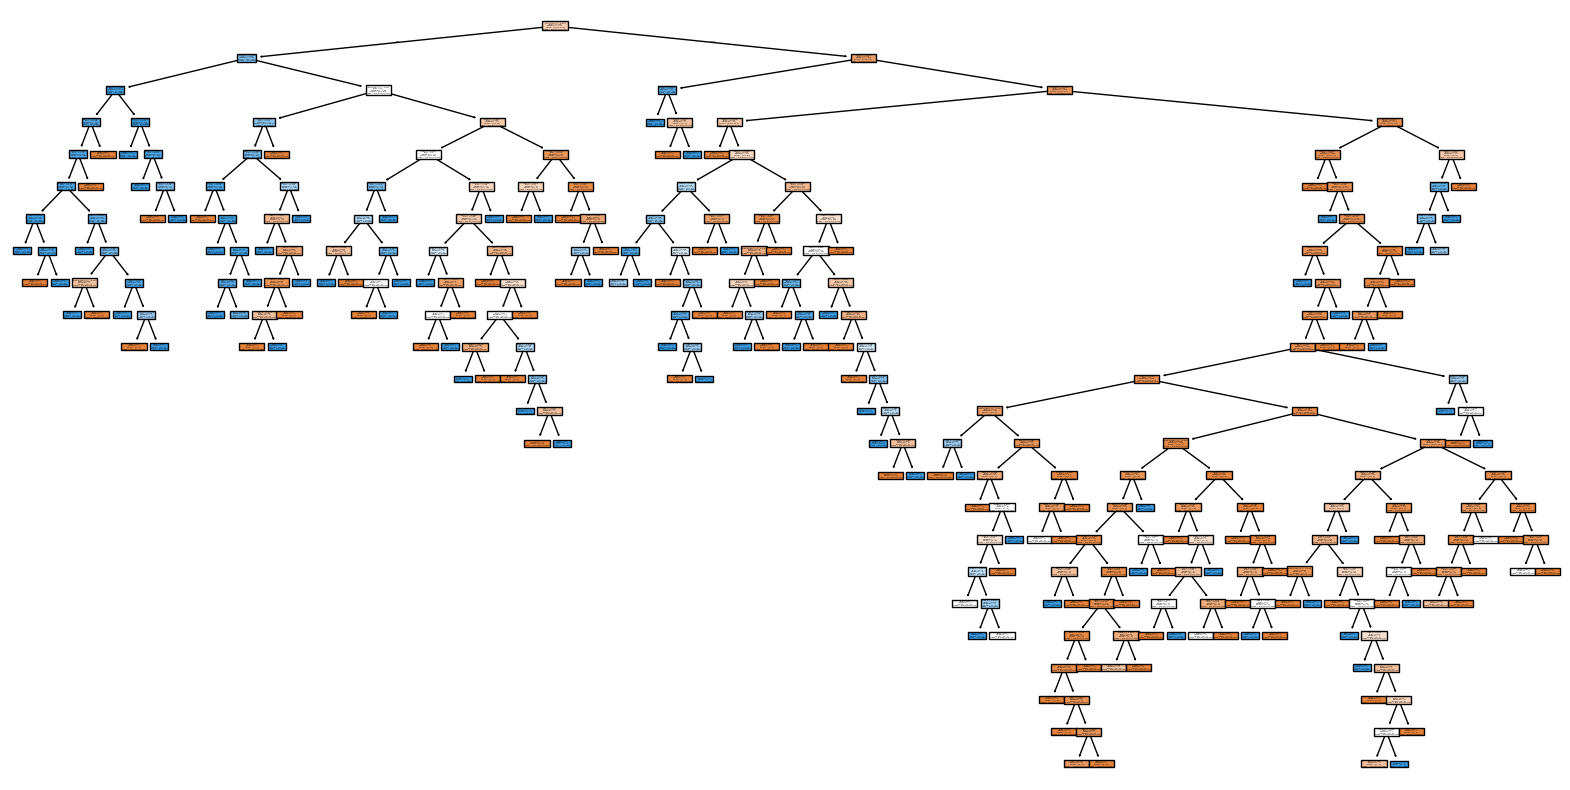

In [ ]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=X_train_encoded.columns,
    class_names=["Did Not Survive", "Survived"],
    filled=True
)

plt.show()

In [ ]:
train_accuracy_tree = tree_model.score(X_train_scaled, y_train)
test_accuracy_tree = tree_model.score(X_test_scaled, y_test)

print("Training Accuracy:", train_accuracy_tree)
print("Testing Accuracy :", test_accuracy_tree)

Training Accuracy: 0.9817415730337079
Testing Accuracy : 0.8212290502793296


In [ ]:
depths = range(1, 16)

train_scores = []
test_scores = []

for depth in depths:

    tree = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train_scaled, y_train)

    train_scores.append(tree.score(X_train_scaled, y_train))
    test_scores.append(tree.score(X_test_scaled, y_test))

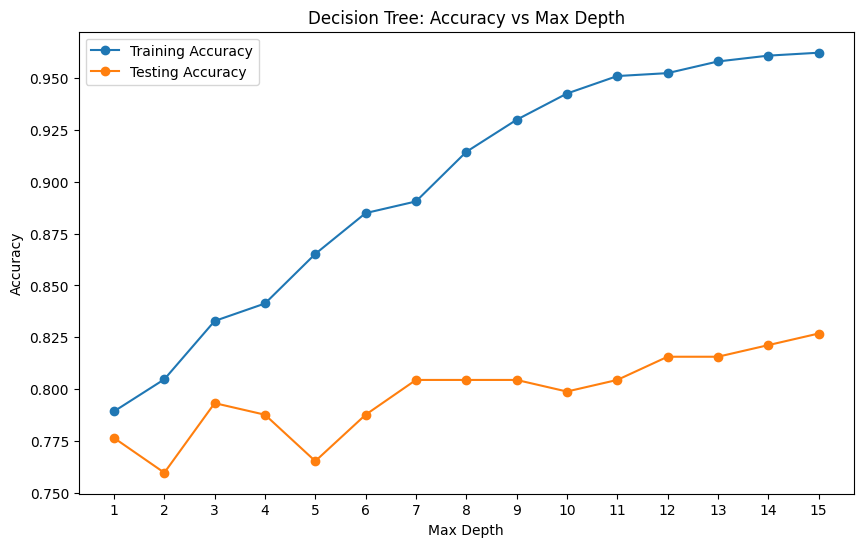

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(depths, train_scores, marker="o", label="Training Accuracy")
plt.plot(depths, test_scores, marker="o", label="Testing Accuracy")

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Accuracy vs Max Depth")
plt.xticks(depths)
plt.legend()

plt.show()

In [ ]:
best_depth = depths[np.argmax(test_scores)]
best_test_accuracy = max(test_scores)

print("Best Depth:", best_depth)
print("Best Test Accuracy:", best_test_accuracy)

Best Depth: 15
Best Test Accuracy: 0.8268156424581006


In [ ]:
from sklearn.model_selection import cross_val_score

depths = range(1, 16)

cv_scores_tree = []

for depth in depths:

    tree = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    scores = cross_val_score(
        tree,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_scores_tree.append(scores.mean())

In [ ]:
best_depth_cv = depths[np.argmax(cv_scores_tree)]
best_cv_accuracy_tree = max(cv_scores_tree)

print("Best Depth:", best_depth_cv)
print("Best CV Accuracy:", best_cv_accuracy_tree)

Best Depth: 5
Best CV Accuracy: 0.8174825174825175


In [ ]:
final_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=best_depth_cv,
    random_state=42
)

final_tree.fit(X_train_scaled, y_train)

final_tree_pred = final_tree.predict(X_test_scaled)

In [ ]:
final_tree_accuracy = accuracy_score(y_test, final_tree_pred)
final_tree_precision = precision_score(y_test, final_tree_pred)
final_tree_recall = recall_score(y_test, final_tree_pred)
final_tree_f1 = f1_score(y_test, final_tree_pred)

print("Accuracy :", final_tree_accuracy)
print("Precision:", final_tree_precision)
print("Recall   :", final_tree_recall)
print("F1       :", final_tree_f1)

Accuracy : 0.7653631284916201
Precision: 0.7547169811320755
Recall   : 0.5797101449275363
F1       : 0.6557377049180327


In [ ]:
print("Training Accuracy:",
      final_tree.score(X_train_scaled, y_train))

print("Testing Accuracy:",
      final_tree.score(X_test_scaled, y_test))

Training Accuracy: 0.8651685393258427
Testing Accuracy: 0.7653631284916201


In [ ]:
importance = pd.Series(
    final_tree.feature_importances_,
    index=X_train_encoded.columns
).sort_values(ascending=False)

print(importance)

Sex_male      0.530655
Pclass        0.180404
Age           0.129043
Fare          0.113752
Embarked_S    0.034252
SibSp         0.011150
Parch         0.000745
Embarked_Q    0.000000
dtype: float64


# **final comparison table:**

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM (Linear)",
        "SVM (RBF)",
        "Naive Bayes",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_LR,
        accuracy_knn,
        svm_accuracy,
        rbf_accuracy,
        nb_accuracy,
        final_tree_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_knn),
        svm_precision,
        rbf_precision,
        nb_precision,
        final_tree_precision
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_knn),
        svm_recall,
        rbf_recall,
        nb_recall,
        final_tree_recall
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_knn),
        svm_f1,
        rbf_f1,
        nb_f1,
        final_tree_f1
    ]
})

results.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
1,KNN,0.815642,0.8,0.695652,0.744186
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409
3,SVM (RBF),0.810056,0.843137,0.623188,0.716667
4,Naive Bayes,0.782123,"(0.7272727272727273,)",0.695652,0.711111
2,SVM (Linear),0.776536,0.737705,0.652174,0.692308
5,Decision Tree,0.765363,0.754717,0.579710,0.655738
